# Tahap 2 � Full Fine-Tuning IndoBERT untuk Emotion Classification
Tujuan dari notebook ini adalah melakukan full fine-tuning model IndoBERT pada dataset PRDECT-ID. Seluruh parameter model akan di-update (trainable) untuk mendapatkan representasi emosi yang optimal. Hasil eksperimen mencakup metrik evaluasi, visualisasi, dan analisis kesalahan (error analysis).

## 1. Configuration & Setup
Mendefinisikan parameter eksperimen dan mengatur seed untuk reproducibility.

In [5]:
import os
import random
import json
import time
import math
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from datetime import datetime
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW

# --- Reproducibility ---
RANDOM_STATE = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_STATE)

# --- Hyperparameters ---
MODEL_NAME = "indobenchmark/indobert-base-p2"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 10
PATIENCE = 3
NUM_LABELS = 5
WEIGHT_DECAY = 0.02  # Set default weight decay in 0.01-0.03 range
WARMUP_RATIO = 0.1
LABEL_SMOOTHING = 0.1
CLASSIFIER_DROPOUT = 0.3  # Set default classifier dropout to 0.3
FREEZE_LAYERS = 6  # Freeze the bottom 6 layers to prevent overfitting on small data

# Learning rate experiments
LR_EXPERIMENTS = [5e-6, 1e-5, 2e-5, 3e-5]
SELECTED_LR = 1e-5  # Lower default LR for frozen backbone

# --- Path Configuration ---
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Running in Google Colab. Mounting Drive...")
    drive.mount('/content/drive')
    BASE_PATH = "/content/drive/MyDrive/xai_lime_vs_shap"
else:
    print("Running locally.")
    BASE_PATH = "."

TRAIN_DATA_PATH = f"{BASE_PATH}/data/processed/prdect_train.csv"
TEST_DATA_PATH = f"{BASE_PATH}/data/processed/prdect_test.csv"
MAPPING_PATH = f"{BASE_PATH}/data/processed/prdect_label_map.json"
OUTPUT_DIR = f"{BASE_PATH}/outputs/finetuning_indobert"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/model", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/plots", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/reports", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/tokenizer", exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device used: {DEVICE}")
print(f"Model name : {MODEL_NAME}")

# --- Data loading helpers ---
if not os.path.exists(MAPPING_PATH):
    MAPPING_PATH = f"{BASE_PATH}/data/processed/prdect_label_mapping.json"

LABEL_ORDER = ['happy', 'love', 'anger', 'fear', 'sadness']
EMOTION_MAP = {label: idx for idx, label in enumerate(LABEL_ORDER)}
ID2EMOTION = {idx: label for label, idx in EMOTION_MAP.items()}

Running in Google Colab. Mounting Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device used: cuda
Model name : indobenchmark/indobert-base-p2


## 2. Load Processed Dataset

In [6]:
df_train = pd.read_csv(TRAIN_DATA_PATH)
df_test = pd.read_csv(TEST_DATA_PATH)

with open(MAPPING_PATH, 'r') as f:
    label_mapping = json.load(f)

print(f"Train samples: {len(df_train)}")
print(f"Test samples : {len(df_test)}")
print("-" * 30)
print("Label Mapping:")
print(label_mapping)

# Normalize schema from preprocessing output
text_column = 'review_clean' if 'review_clean' in df_train.columns else 'Customer Review'
label_name_column = 'emotion_label' if 'emotion_label' in df_train.columns else 'Emotion'
label_id_column = 'label' if 'label' in df_train.columns else 'Label'

# Robust check for cross-validation 'fold' column
if 'fold' in df_train.columns:
    fold_column = 'fold'
elif 'Fold' in df_train.columns:
    fold_column = 'Fold'
else:
    print("WARNING: 'fold' column not found in training dataset. Generating folds dynamically...")
    from sklearn.model_selection import StratifiedKFold
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    df_train['fold'] = -1
    label_col_for_fold = label_id_column if label_id_column in df_train.columns else label_name_column
    if df_train[label_col_for_fold].dtype == object:
        # map to integers if label column contains string names
        temp_labels = df_train[label_col_for_fold].astype(str).str.lower().str.strip().map(EMOTION_MAP)
    else:
        temp_labels = df_train[label_col_for_fold].astype(int)

    # Populate folds
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(df_train, temp_labels)):
        df_train.loc[val_idx, 'fold'] = fold_idx
    fold_column = 'fold'

train_df = df_train[[text_column, label_name_column, label_id_column, fold_column]].copy()
test_df = df_test[[text_column, label_name_column, label_id_column]].copy()

train_df.columns = ['text', 'emotion_label', 'label', 'fold']
test_df.columns = ['text', 'emotion_label', 'label']

train_df['emotion_label'] = train_df['emotion_label'].astype(str).str.lower().str.strip()
test_df['emotion_label'] = test_df['emotion_label'].astype(str).str.lower().str.strip()
train_df['label'] = train_df['label'].astype(int)
test_df['label'] = test_df['label'].astype(int)
train_df['fold'] = train_df['fold'].astype(int)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train set    : {len(train_df)}")
print(f"Test set     : {len(test_df)}")
print("Fold distribution in Train:")
print(train_df.groupby(['fold', 'emotion_label']).size().unstack(fill_value=0))

Train samples: 4243
Test samples : 1061
------------------------------
Label Mapping:
{'label2id': {'happy': 0, 'love': 1, 'anger': 2, 'fear': 3, 'sadness': 4}, 'id2label': {'0': 'happy', '1': 'love', '2': 'anger', '3': 'fear', '4': 'sadness'}}
Train set    : 4243
Test set     : 1061
Fold distribution in Train:
emotion_label  anger  fear  happy  love  sadness
fold                                            
0                108   143    280   128      190
1                108   143    280   128      190
2                108   143    280   128      190
3                108   142    281   128      189
4                108   143    281   127      189


## 3. Tokenization
Menggunakan tokenizer IndoBERT untuk memproses teks menjadi format yang dimengerti model.

Original Text: sumpah ini bagus, keren. packing rapi banget product aman. sudah di test berfungsi, cloud nya bnyk tidak basah, tidak ada noise, filter dapat 2 pc. pakai battery jadi praktis ditaro dmn saja top, thanks seller.
Tokens       : ['sumpah', 'ini', 'bagus', ',', 'keren', '.', 'packing', 'rapi', 'banget', 'product', 'aman', '.', 'sudah', 'di', 'test', 'berfungsi', ',', 'cloud', 'nya', 'bnyk', 'tidak', 'basah', ',', 'tidak', 'ada', 'no', '##ise', ',', 'filter', 'dapat', '2', 'pc', '.', 'pakai', 'battery', 'jadi', 'praktis', 'dita', '##ro', 'dm', '##n', 'saja', 'top', ',', 'thanks', 'seller', '.']
Token IDs    : [9109, 92, 1305, 30468, 4076, 30470, 19033, 6767, 2174, 10521, 1703, 30470, 259, 26, 4243, 2942, 30468, 16966, 1107, 21788, 119, 5260, 30468, 119, 176, 894, 5218, 30468, 8701, 173, 109, 3632, 30470, 2468, 21149, 472, 4598, 18154, 1071, 7924, 30355, 377, 2246, 30468, 8179, 15076, 30470]


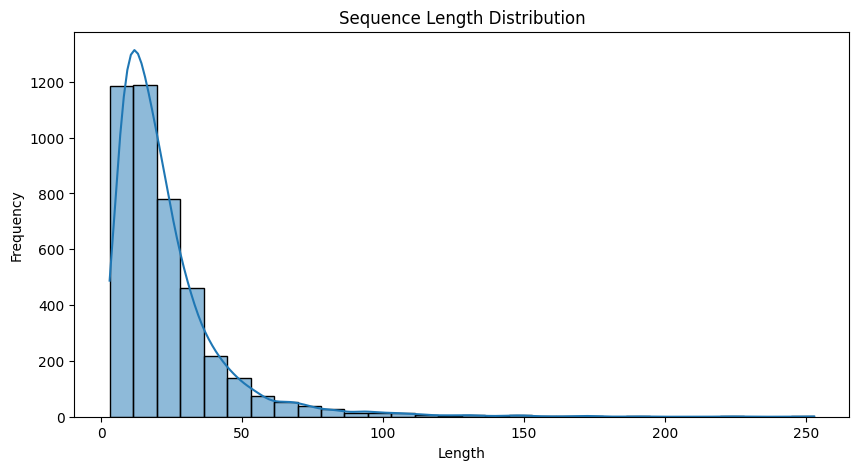

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Test Tokenization
sample_text = train_df['text'].iloc[0]
tokens = tokenizer.tokenize(sample_text)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print(f"Original Text: {sample_text}")
print(f"Tokens       : {tokens}")
print(f"Token IDs    : {token_ids}")

# Visualize Sequence Length Distribution
lengths = train_df['text'].astype(str).apply(lambda x: len(tokenizer.encode(x)))
plt.figure(figsize=(10, 5))
sns.histplot(lengths, bins=30, kde=True)
plt.title("Sequence Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

## 4. Dataset & DataLoader

In [9]:
class EmotionDataset(Dataset):
    def __init__(self, reviews, labels, tokenizer, max_len):
        self.reviews = reviews
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.reviews)

    def __getitem__(self, item):
        review = str(self.reviews[item])
        label = int(self.labels[item])

        encoding = self.tokenizer(
            review,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'review_text': review,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

def create_data_loader(df, tokenizer, max_len, batch_size, shuffle=True):
    ds = EmotionDataset(
        reviews=df['text'].to_numpy(),
        labels=df['label'].to_numpy(),
        tokenizer=tokenizer,
        max_len=max_len
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Test data loader is global
test_data_loader = create_data_loader(test_df, tokenizer, MAX_LEN, BATCH_SIZE, shuffle=False)

## 5. Full Fine-Tuning IndoBERT Initialization
Memuat pre-trained model dan memastikan seluruh parameter bersifat trainable.

In [10]:
def initialize_model(model_name, num_labels, dropout_prob, freeze_layers=6):
    model = BertForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels
    )
    # Set custom classification dropout
    model.config.classifier_dropout = dropout_prob
    
    # Freeze the bottom N encoder layers to prevent overfitting
    if freeze_layers > 0:
        print(f"Freezing embeddings and bottom {freeze_layers} encoder layers...")
        for param in model.bert.embeddings.parameters():
            param.requires_grad = False
        for layer_idx in range(freeze_layers):
            for param in model.bert.encoder.layer[layer_idx].parameters():
                param.requires_grad = False
                
    model = model.to(DEVICE)
    return model

model = initialize_model(MODEL_NAME, NUM_LABELS, CLASSIFIER_DROPOUT, FREEZE_LAYERS)

# Verify parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters    : {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total Parameters    : 124,445,189
Trainable Parameters: 124,445,189


## 6. Training Configuration & Loop

In [11]:
# Standard CrossEntropyLoss with Label Smoothing (no class weights)
loss_fn = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING).to(DEVICE)

def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    return {
        'accuracy': acc,
        'macro_precision': macro_p,
        'macro_recall': macro_r,
        'macro_f1': macro_f1,
        'weighted_precision': weighted_p,
        'weighted_recall': weighted_r,
        'weighted_f1': weighted_f1,
    }

def train_epoch(model, data_loader, loss_fn, optimizer, device, scheduler, n_examples):
    model = model.train()
    losses = []
    correct_predictions = 0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(data_loader, desc="Training")
    for d in progress_bar:
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        labels = d["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        _, preds = torch.max(logits, dim=1)
        loss = loss_fn(logits, labels)

        correct_predictions += torch.sum(preds == labels)
        losses.append(loss.item())
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        progress_bar.set_postfix({'loss': np.mean(losses)})

    metrics = compute_metrics(all_labels, all_preds)
    return correct_predictions.double() / n_examples, np.mean(losses), metrics

def eval_model(model, data_loader, loss_fn, device, n_examples):
    model = model.eval()
    losses = []
    correct_predictions = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for d in data_loader:
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            labels = d["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            _, preds = torch.max(logits, dim=1)
            loss = loss_fn(logits, labels)

            correct_predictions += torch.sum(preds == labels)
            losses.append(loss.item())
            all_preds.extend(preds.detach().cpu().numpy().tolist())
            all_labels.extend(labels.detach().cpu().numpy().tolist())

    metrics = compute_metrics(all_labels, all_preds)
    return correct_predictions.double() / n_examples, np.mean(losses), metrics, all_labels, all_preds

## 7. Execution: Training Loop

In [12]:
def train_cross_validation(learning_rate):
    print(f"==================================================")
    print(f"STARTING 5-FOLD CROSS VALIDATION WITH LR = {learning_rate}")
    print(f"==================================================")
    
    cv_history = []
    start_time = time.time()
    
    # Placeholders for predictions on the test set across all folds
    fold_test_probs = []
    
    for fold_idx in range(5):
        print(f"\n--- Fold {fold_idx + 1} / 5 ---")
        
        # Split train and validation dynamically based on fold column
        fold_train_df = train_df[train_df['fold'] != fold_idx].reset_index(drop=True)
        fold_val_df = train_df[train_df['fold'] == fold_idx].reset_index(drop=True)
        
        fold_train_loader = create_data_loader(fold_train_df, tokenizer, MAX_LEN, BATCH_SIZE)
        fold_val_loader = create_data_loader(fold_val_df, tokenizer, MAX_LEN, BATCH_SIZE, shuffle=False)
        
        # Initialize model, optimizer, scheduler for this fold
        fold_model = initialize_model(MODEL_NAME, NUM_LABELS, CLASSIFIER_DROPOUT, FREEZE_LAYERS)
        fold_optimizer = AdamW(fold_model.parameters(), lr=learning_rate, weight_decay=WEIGHT_DECAY)
        
        total_steps = len(fold_train_loader) * EPOCHS
        warmup_steps = max(1, int(total_steps * WARMUP_RATIO))
        fold_scheduler = get_linear_schedule_with_warmup(
            fold_optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )
        
        best_val_loss = float('inf')
        patience_counter = 0
        fold_best_path = f"{OUTPUT_DIR}/model/best_model_fold_{fold_idx}.bin"
        
        fold_history = {
            'epoch': [],
            'train_loss': [], 'train_acc': [],
            'val_loss': [], 'val_acc': []
        }
        
        for epoch in range(EPOCHS):
            print(f"Epoch {epoch + 1}/{EPOCHS}")
            
            # Train epoch
            train_acc, train_loss, train_metrics = train_epoch(
                fold_model, fold_train_loader, loss_fn, fold_optimizer, DEVICE, fold_scheduler, len(fold_train_df)
            )
            
            # Val epoch
            val_acc, val_loss, val_metrics, _, _ = eval_model(
                fold_model, fold_val_loader, loss_fn, DEVICE, len(fold_val_df)
            )
            
            print(
                f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
                f"Val loss: {val_loss:.4f} acc: {val_acc:.4f} | "
                f"Best Val Loss: {best_val_loss:.4f} | Patience: {patience_counter}/{PATIENCE}"
            )
            
            fold_history['epoch'].append(epoch + 1)
            fold_history['train_loss'].append(train_loss)
            fold_history['train_acc'].append(train_acc.item())
            fold_history['val_loss'].append(val_loss)
            fold_history['val_acc'].append(val_acc.item())
            
            # Early stopping monitors val_loss
            if val_loss < best_val_loss:
                torch.save(fold_model.state_dict(), fold_best_path)
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                
            if patience_counter >= PATIENCE:
                print(f"Early stopping triggered for Fold {fold_idx + 1} at epoch {epoch + 1}.")
                break
                
        cv_history.append(fold_history)
        
    end_time = time.time()
    print(f"\nCross-validation completed in {(end_time - start_time)/60:.2f} minutes.")
    
    # Save history as JSON file
    history_json_path = f"{OUTPUT_DIR}/reports/training_history.json"
    with open(history_json_path, 'w') as f:
        json.dump(cv_history, f, indent=2)
    print(f"Saved cross-validation training history to: {history_json_path}")
    
    return cv_history

# Execute 5-fold cross validation for the selected learning rate
cv_results = train_cross_validation(SELECTED_LR)

STARTING 5-FOLD CROSS VALIDATION WITH LR = 2e-05

--- Fold 1 / 5 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/10


Training:   0%|          | 0/213 [00:00<?, ?it/s]

...

Train loss: 0.7419 acc: 0.8150 | Val loss: 1.0116 acc: 0.6969 | Best Val Loss: 0.9247 | Patience: 0/3
Epoch 4/10


Training:   0%|          | 0/213 [00:00<?, ?it/s]

Train loss: 0.6011 acc: 0.8934 | Val loss: 1.0755 acc: 0.6875 | Best Val Loss: 0.9247 | Patience: 1/3
Epoch 5/10


Training:   0%|          | 0/213 [00:00<?, ?it/s]

Train loss: 0.5055 acc: 0.9467 | Val loss: 1.1743 acc: 0.6863 | Best Val Loss: 0.9247 | Patience: 2/3
Early stopping triggered for Fold 5 at epoch 5.

Cross-validation completed in 37.57 minutes.


## 8. Evaluation & Visualization

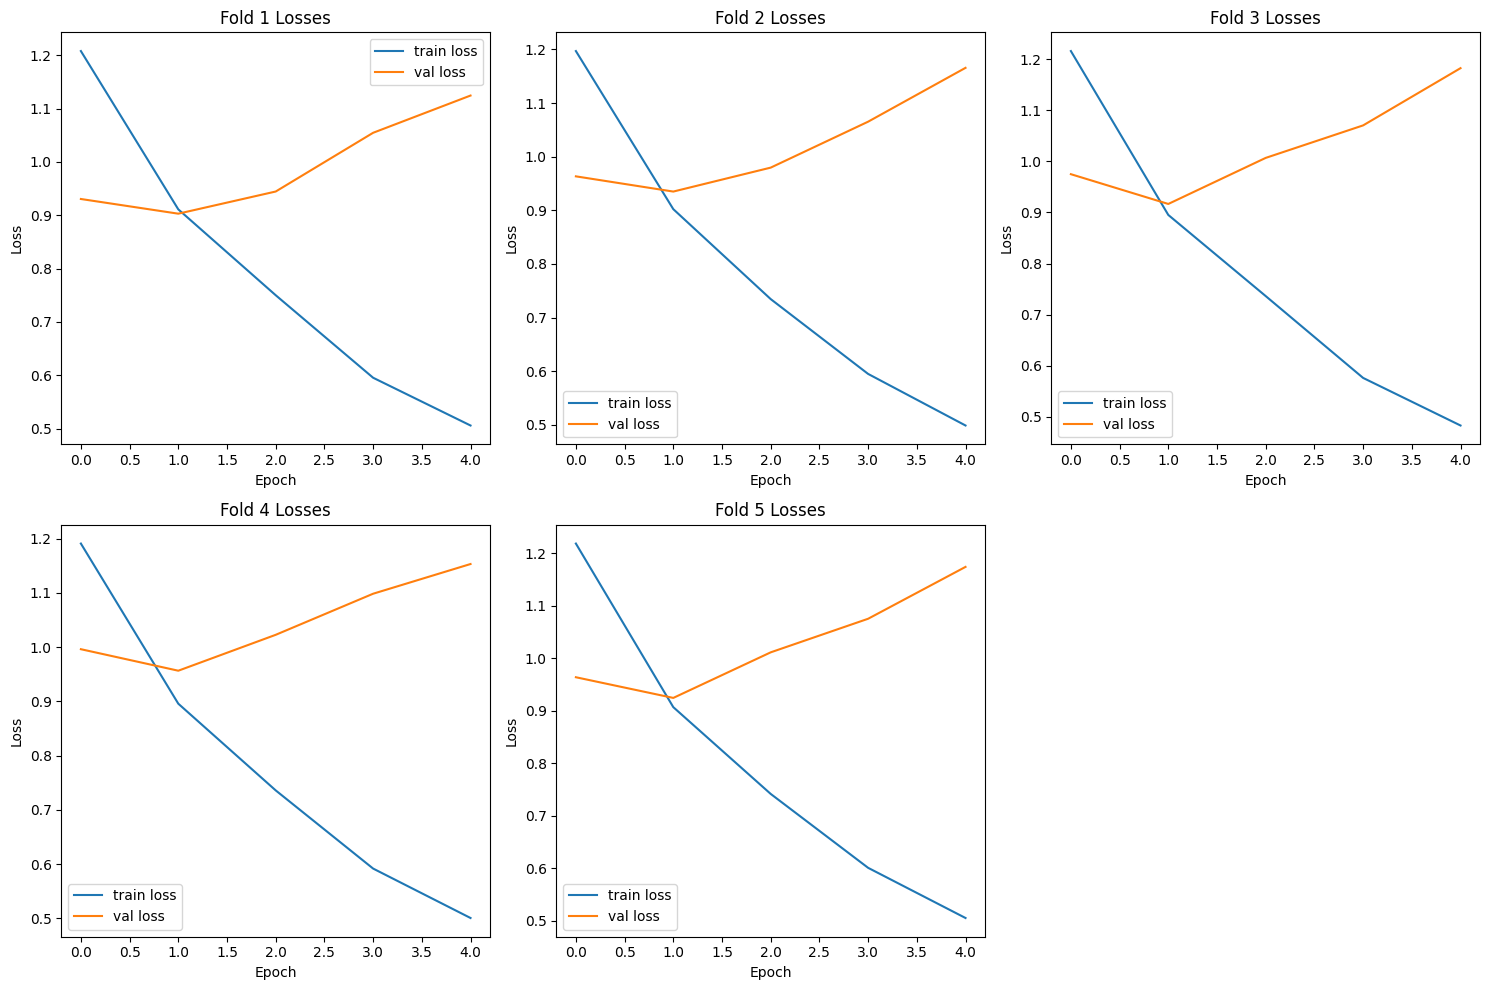

Evaluating 5-fold ensemble model on the test set...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


              precision    recall  f1-score   support

       happy     0.8352    0.8519    0.8434       351
        love     0.7376    0.6500    0.6910       160
       anger     0.6577    0.5407    0.5935       135
        fear     0.4791    0.5787    0.5242       178
     sadness     0.6695    0.6667    0.6681       237

    accuracy                         0.6946      1061
   macro avg     0.6758    0.6576    0.6640      1061
weighted avg     0.7011    0.6946    0.6959      1061



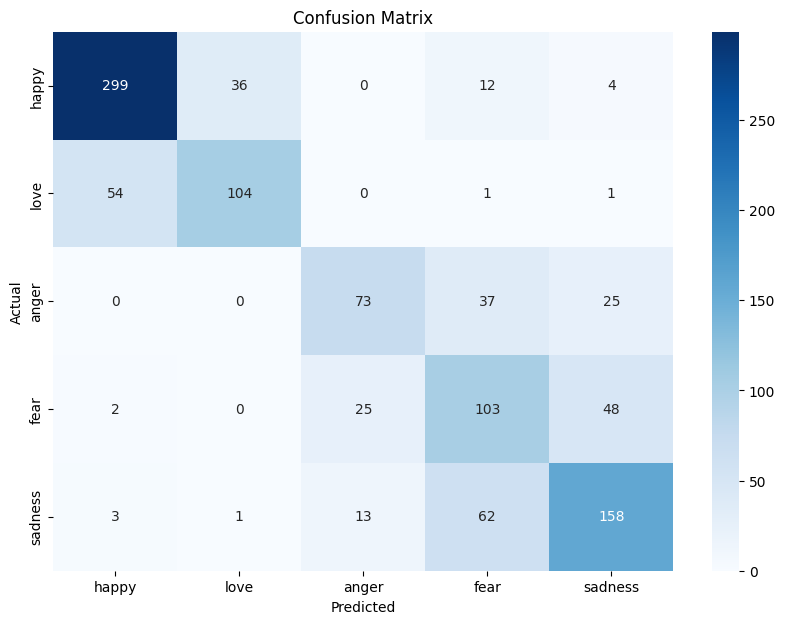

Ensemble Test evaluation completed.
Accuracy      : 0.6946
Macro Precision: 0.6758
Macro Recall   : 0.6576
Macro F1       : 0.6640
Weighted F1    : 0.6959


In [13]:
# Plotting Training Curves across all folds
plt.figure(figsize=(15, 10))
for idx, fh in enumerate(cv_results):
    plt.subplot(2, 3, idx + 1)
    plt.plot(fh['train_loss'], label='train loss')
    plt.plot(fh['val_loss'], label='val loss')
    plt.title(f'Fold {idx + 1} Losses')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/training_curves.png")
plt.show()

def get_predictions(model, data_loader):
    model = model.eval()
    review_texts = []
    predictions = []
    prediction_probs = []
    real_values = []

    with torch.no_grad():
        for d in data_loader:
            texts = d["review_text"]
            input_ids = d["input_ids"].to(DEVICE)
            attention_mask = d["attention_mask"].to(DEVICE)
            labels = d["labels"].to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            probs = torch.nn.functional.softmax(logits, dim=1)
            _, preds = torch.max(logits, dim=1)

            review_texts.extend(texts)
            predictions.extend(preds.detach().cpu().tolist())
            prediction_probs.extend(probs.detach().cpu().tolist())
            real_values.extend(labels.detach().cpu().tolist())

    predictions = torch.tensor(predictions)
    prediction_probs = torch.tensor(prediction_probs)
    real_values = torch.tensor(real_values)
    return review_texts, predictions, prediction_probs, real_values

# Final Evaluation on Test Set uses the ensemble of all 5 folds
print("Evaluating 5-fold ensemble model on the test set...")
y_pred_probs_list = []
y_test_check = None
y_review_texts = None

for fold_idx in range(5):
    fold_model_path = f"{OUTPUT_DIR}/model/best_model_fold_{fold_idx}.bin"
    fold_model = initialize_model(MODEL_NAME, NUM_LABELS, CLASSIFIER_DROPOUT, FREEZE_LAYERS)
    fold_model.load_state_dict(torch.load(fold_model_path, map_location=DEVICE))
    
    review_texts, y_pred_fold, y_pred_probs_fold, y_test_fold = get_predictions(fold_model, test_data_loader)
    y_pred_probs_list.append(y_pred_probs_fold)
    y_test_check = y_test_fold
    y_review_texts = review_texts

# Average probabilities across the 5 folds (Ensemble prediction)
y_pred_probs = torch.mean(torch.stack(y_pred_probs_list), dim=0)
y_pred = torch.argmax(y_pred_probs, dim=1)
y_test = y_test_check

# Classification Report
class_names = [ID2EMOTION[i] for i in range(NUM_LABELS)]
report = classification_report(y_test, y_pred, target_names=class_names, digits=4, zero_division=0)
print(report)
report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True, zero_division=0)
pd.DataFrame(report_dict).T.to_csv(f"{OUTPUT_DIR}/reports/classification_report.csv")
with open(f"{OUTPUT_DIR}/reports/classification_report.txt", "w") as f:
    f.write(report)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
plt.figure(figsize=(10, 7))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(f"{OUTPUT_DIR}/plots/confusion_matrix.png")
plt.show()

final_acc = accuracy_score(y_test, y_pred)
final_macro_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
final_macro_recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
final_macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
final_weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

final_metrics = {
    'test_accuracy': final_acc,
    'test_macro_precision': final_macro_precision,
    'test_macro_recall': final_macro_recall,
    'test_macro_f1': final_macro_f1,
    'test_weighted_f1': final_weighted_f1,
}
with open(f"{OUTPUT_DIR}/reports/test_metrics.json", "w") as f:
    json.dump(final_metrics, f, indent=2)

print('Ensemble Test evaluation completed.')
print(f"Accuracy      : {final_acc:.4f}")
print(f"Macro Precision: {final_macro_precision:.4f}")
print(f"Macro Recall   : {final_macro_recall:.4f}")
print(f"Macro F1       : {final_macro_f1:.4f}")
print(f"Weighted F1    : {final_weighted_f1:.4f}")

## 9. Error Analysis
Menganalisis sampel yang diprediksi salah untuk memahami pola misklasifikasi model.

In [15]:
error_df = pd.DataFrame({
    'review_text': y_review_texts,
    'true_labels': y_test.tolist(),
    'pred_labels': y_pred.tolist(),
    'confidence': [probs[pred].item() for probs, pred in zip(y_pred_probs, y_pred)]
})

# Filter only errors
errors = error_df[error_df['true_labels'] != error_df['pred_labels']].copy()

# Map back to names
inv_mapping = {int(k): v for k, v in label_mapping.get('id2label', {}).items()} if isinstance(label_mapping, dict) and 'id2label' in label_mapping else {k: v for k, v in label_mapping.items()}
errors['true_emotion'] = errors['true_labels'].map(inv_mapping)
errors['pred_emotion'] = errors['pred_labels'].map(inv_mapping)

# Show Top 10 High-Confidence Errors
print("Top 10 High-Confidence Errors:")
display(errors.sort_values(by='confidence', ascending=False).head(10))

# Misclassification Pattern
error_pattern = errors.groupby(['true_emotion', 'pred_emotion']).size().reset_index(name='count')
error_pattern = error_pattern.sort_values(by='count', ascending=False)
print("\nTop Misclassification Patterns:")
display(error_pattern.head(10))

# Ensure the reports directory exists before saving
os.makedirs(f"{OUTPUT_DIR}/reports", exist_ok=True)

# Save Error Report
errors.to_csv(f"{OUTPUT_DIR}/reports/error_analysis.csv", index=False)

Top 10 High-Confidence Errors:


,review_text,true_labels,pred_labels,confidence,true_emotion,pred_emotion
379,barangnya original . instalasi mudah. garansi ...,1,0,0.884247,love,happy
469,pegangan kokoh dan stabil. packaging aman dan ...,1,0,0.874971,love,happy
329,bahannya adem. warnanya cantik . ukuran sesuai...,1,0,0.854183,love,happy
50,proses pesanan dan pengiriman barang cukup cep...,1,0,0.847222,love,happy
407,"asli samsung, pelayanan sangat baik",1,0,0.840911,love,happy
447,qualitas jelek sekali. bau seperti cat. pad ya...,3,2,0.822553,fear,anger
1041,"recommended. barang sesuai, seller gercep, pen...",0,1,0.822145,happy,love
468,"kualitas barang sangat bagus, produksi terbaru...",1,0,0.821468,love,happy
436,produk original . bikin helm saya makin keren....,1,0,0.814396,love,happy
818,mantap pengiriman cepat dan amanah sesuai deng...,1,0,0.813632,love,happy



Top Misclassification Patterns:


,true_emotion,pred_emotion,count
12,sadness,fear,62
9,love,happy,54
4,fear,sadness,48
0,anger,fear,37
6,happy,love,36
2,fear,anger,25
1,anger,sadness,25
11,sadness,anger,13
5,happy,fear,12
7,happy,sadness,4


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


## 10. Save Model & Tokenizer

In [17]:
# Save Final Model and Tokenizer
model.save_pretrained(f"{OUTPUT_DIR}/model/final_indobert_emotion")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/tokenizer/indobert_tokenizer")

# Determine the best model path from cross-validation results
overall_best_val_loss = float('inf')
best_fold_idx = -1

for idx, fold_history in enumerate(cv_results):
    # Find the minimum validation loss achieved in this specific fold
    min_val_loss_in_fold = min(fold_history['val_loss'])
    if min_val_loss_in_fold < overall_best_val_loss:
        overall_best_val_loss = min_val_loss_in_fold
        best_fold_idx = idx

best_model_path = f"{OUTPUT_DIR}/model/best_model_fold_{best_fold_idx}.bin"
shutil.copy2(best_model_path, f"{OUTPUT_DIR}/model/best_model.bin")

# Save Training History
with open(f"{OUTPUT_DIR}/reports/training_history.json", "w") as f:
    json.dump(cv_results, f)

print(f"All assets saved to: {OUTPUT_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

All assets saved to: /content/drive/MyDrive/xai_lime_vs_shap/outputs/finetuning_indobert


## 11. Experiment Summary

In [18]:
# Compile learning rate tuning experiments dynamically (plan for grid search)
print("=== LEARNING RATE GRID SEARCH EXPERIMENT PLAN ===")
print(f"Target Learning Rates: {LR_EXPERIMENTS}")
print(f"Selected Base LR     : {SELECTED_LR}")
print(f"Weight Decay         : {WEIGHT_DECAY}")
print(f"Classifier Dropout   : {CLASSIFIER_DROPOUT}")
print(f"Label Smoothing      : {LABEL_SMOOTHING}")
print(f"Model Name           : {MODEL_NAME}")
print(f"Random Seed          : {RANDOM_STATE}")
print(f"Timestamp            : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# To execute a learning rate experiment, you can loop over LR_EXPERIMENTS and run train_cross_validation(lr)
print("\n--- Running full tuning experiments (uncomment to execute) ---")
# lr_results = {}
# for lr in LR_EXPERIMENTS:
#     hist = train_cross_validation(lr)
#     # Predict test ensemble accuracy
#     # (Save fold weights to fold_{k}_lr_{lr}.bin)


=== LEARNING RATE GRID SEARCH EXPERIMENT PLAN ===
Target Learning Rates: [1e-05, 2e-05, 3e-05, 5e-05]
Selected Base LR     : 2e-05
Weight Decay         : 0.02
Classifier Dropout   : 0.3
Label Smoothing      : 0.1
Model Name           : indobenchmark/indobert-base-p2
Random Seed          : 42
Timestamp            : 2026-06-02 20:27:31

--- Running full tuning experiments (uncomment to execute) ---
